In [5]:
import pandas as pd

In [6]:
df= pd.read_csv('loan_data.csv')
df.head()

,customer_id,gender,city,employment_status,repayment_status,income_ghs,loan_amount_ghs,age
0,1,Female,Koforidua,Freelancer,Default,25800,95194,41
1,2,Male,Kumasi,Employed,Partial,41477,26929,42
2,3,Female,Ho,Unemployed,Partial,28931,66697,49
3,4,Female,Mankesim,Unemployed,Paid,15459,315,33
4,5,Male,Techiman,Small Business Owner,Default,1224,53751,26


In [7]:
#Counting how many Males and Females defaulted.
df['gender'][df['repayment_status']== 'Default'].value_counts()

,count
gender,
Female,186
Male,181


The Higher number of Males could be as a result of more males taking loan than females. To properly investigate, lets find the
percentage of males in the Dataset that defaulted Vs the percentage of Females that also defaulted.

In [8]:
#First of all, we find the total number of females and males.
df['gender'].value_counts()

,count
gender,
Female,508
Male,492


In [9]:
Percentage_males_defaulted = 194/525 * 100
Percentage_females_defaulted = 164/475 * 100
print(f'Percentage of Males that defaulted = {Percentage_males_defaulted}\nPercentage of Females that defaulted = {Percentage_females_defaulted}')

Percentage of Males that defaulted = 36.952380952380956
Percentage of Females that defaulted = 34.526315789473685


So we realise that Gender alone doesn't affect Loan repayment since the percentage difference isn't much.
Lets see how age groups can also affect Loan repayment.

In [10]:
average_age_default= df[df['repayment_status']== 'Default']['age'].mean()
average_age_paid= df[df['repayment_status']== 'Paid']['age'].mean()
average_age_partial= df[df['repayment_status']== 'Partial']['age'].mean()
print(f'average age of defaulters = {average_age_default}\naverage age of Paid in full = {average_age_paid}\naverage age of partial payments = {average_age_partial}')


average age of defaulters = 38.37602179836512
average age of Paid in full = 38.01273885350319
average age of partial payments = 38.912225705329156


Age alone doesn't affect loan Repayment.
Lets move on to Income

In [11]:
average_income_default= df[df['repayment_status']=='Default']['income_ghs'].mean()
average_income_paid= df[df['repayment_status']=='Paid']['income_ghs'].mean()
average_income_partial= df[df['repayment_status']=='Partial']['income_ghs'].mean()
print(f'average income of defaulters = {average_income_default}\naverage income of Paid in full = {average_income_paid}\naverage imcome of partial payments = {average_income_partial}')

average income of defaulters = 22962.125340599454
average income of Paid in full = 24928.267515923566
average imcome of partial payments = 24958.84326018809


Could income alone be misleading here?

Consider this scenario:

	•	Person A earns GHS 25,000 and took a loan of GHS 5,000
	•	Person B earns GHS 25,000 and took a loan of GHS 90,000

Same income — but are they in the same position to repay?
The answer is no so we focus on the ratio of Loan-to-Income.
Since we don't have such a column, we create one.


In [12]:
df['Loan_to_Income_ratio'] = df['income_ghs'] / df['loan_amount_ghs']
df['Loan_to_Income_ratio']

,Loan_to_Income_ratio
0,0.271025
1,1.540235
2,0.433768
3,49.076190
4,0.022772
...,...
995,10.558528
996,1.092722
997,3.105029
998,0.108283


In [13]:
df

,customer_id,gender,city,employment_status,repayment_status,income_ghs,loan_amount_ghs,age,Loan_to_Income_ratio
0,1,Female,Koforidua,Freelancer,Default,25800,95194,41,0.271025
1,2,Male,Kumasi,Employed,Partial,41477,26929,42,1.540235
2,3,Female,Ho,Unemployed,Partial,28931,66697,49,0.433768
3,4,Female,Mankesim,Unemployed,Paid,15459,315,33,49.076190
4,5,Male,Techiman,Small Business Owner,Default,1224,53751,26,0.022772
...,...,...,...,...,...,...,...,...,...
995,996,Female,Aburi,Big Business Owner,Default,34727,3289,23,10.558528
996,997,Male,Cape Coast,Employed,Partial,33092,30284,24,1.092722
997,998,Female,Ho,Big Business Owner,Default,39822,12825,43,3.105029
998,999,Male,Aburi,Small Business Owner,Partial,5709,52723,37,0.108283


In [14]:
Loan_to_Income_ratio_defaulters= df[df['repayment_status']=='Default']['Loan_to_Income_ratio'].mean()
Loan_to_Income_ratio_paid= df[df['repayment_status']=='Paid']['Loan_to_Income_ratio'].mean()
Loan_to_Income_ratio_partial= df[df['repayment_status']=='Partial']['Loan_to_Income_ratio'].mean()
print(f'Loan to Income ratio of Defaulters= {Loan_to_Income_ratio_defaulters}\nLoan to Income ratio of Paid in full= {Loan_to_Income_ratio_paid}\nLoan to Income ratio of Partial= {Loan_to_Income_ratio_partial}')

Loan to Income ratio of Defaulters= 1.389727854364777
Loan to Income ratio of Paid in full= 2.1741225937367625
Loan to Income ratio of Partial= 1.4739579630985078


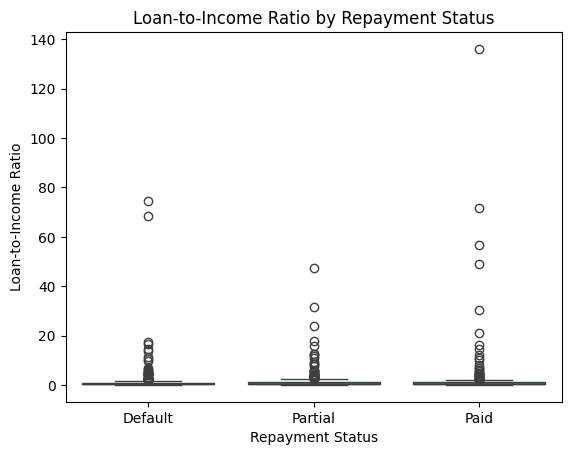

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df, x='repayment_status', y='Loan_to_Income_ratio')
plt.title('Loan-to-Income Ratio by Repayment Status')
plt.xlabel('Repayment Status')
plt.ylabel('Loan-to-Income Ratio')
plt.show()


## **Lets find out how employment status affects loan repayment.**
We will first count how many employment status defaulted.

In [17]:
df['employment_status'][df['repayment_status']=='Default'].value_counts()

,count
employment_status,
Employed,81
Small Business Owner,77
Unemployed,75
Freelancer,73
Big Business Owner,61


Find the total number of the various employment categories.

In [20]:
df['employment_status'].value_counts()

,count
employment_status,
Employed,222
Unemployed,202
Freelancer,197
Big Business Owner,193
Small Business Owner,186


Find the percentage of employment status that defaulted.

In [24]:
employed_default = 81/222 * 100
unemployed_default = 75/202 * 100
freelancer= 73/197 * 100
big_Business= 61/193 * 100
small_business= 77/186 * 100
print(f'Percentage of Employed that defaulted = {employed_default}\nPercentage of Unemployed that defaulted = {unemployed_default}\nPercentage of Freelancer = {freelancer}\nPercentage of Big Business = {big_Business}\nPercentage of Small Business = {small_business}')

Percentage of Employed that defaulted = 36.486486486486484
Percentage of Unemployed that defaulted = 37.12871287128713
Percentage of Freelancer = 37.055837563451774
Percentage of Big Business = 31.606217616580313
Percentage of Small Business = 41.39784946236559


From this we realize that Small business defaulted the most and big business defaulted the least which makes sense. What is suprising is how small business defaulted more than unemployed individuals. Some reasons could include, small businesses are more exposed to economic shocks like inflation and currency depreciation, which directly eat into their revenue and ability to repay.

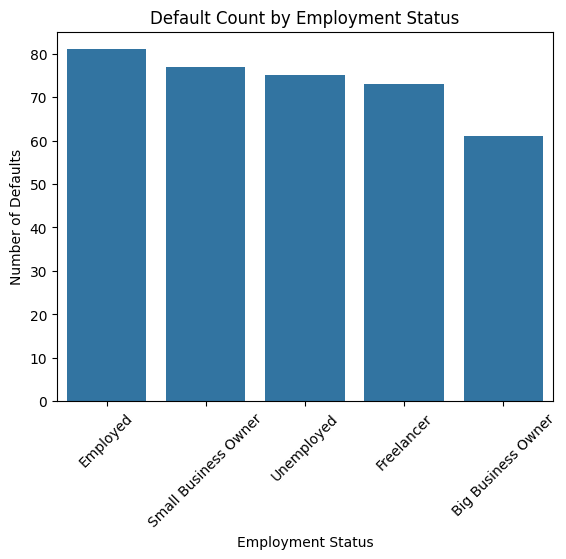

In [26]:
employment_default = df[df['repayment_status'] == 'Default']['employment_status'].value_counts()

sns.barplot(x=employment_default.index, y=employment_default.values)
plt.title('Default Count by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Number of Defaults')
plt.xticks(rotation=45)
plt.show()